# **[1] 이미지 분류 개요**


### **Part1. 이미지 분류란?**

---

### **1. 정의**

이미지 분류(Image Classification)는 입력된 이미지를 **사전 정의된 클래스** 중 하나로 분류하는 작업입니다. 딥러닝의 핵심 응용 분야 중 하나로, 컴퓨터가 이미지 데이터를 이해하고 분석하여 특정 클래스를 예측하는 과정입니다.

- **입력**: 이미지 데이터 (예: 고양이 사진)
- **출력**: 클래스 레이블 (예: "Cat" 또는 "Dog")

이미지 분류 모델은 주로 CNN(Convolutional Neural Network)과 같은 딥러닝 모델을 사용하여 데이터로부터 특징을 학습합니다.

**CNN의 구조적 흐름** 및 구체적인 작동 방식은 이후 섹션에서 자세히 다룹니다.

### **2. 이미지 분류의 주요 구성 요소**

이미지 분류 작업은 다음과 같은 구성 요소를 기반으로 이루어집니다.

### **1) 입력 데이터**

- 모델이 처리할 이미지 데이터로, **고차원 픽셀 값**으로 구성됩니다.
    - RGB 이미지: 가로 × 세로 × 3 채널.
    - Grayscale 이미지: 가로 × 세로 × 1 채널.
- 입력 이미지는 모델 학습을 위해 크기 조정, 정규화 등 **전처리**가 필요합니다.

### **2) 출력 데이터**

- 모델은 입력 이미지에 기반하여 특정 클래스 레이블을 예측합니다.
    - 예: 개와 고양이 분류 모델 → 출력 레이블: "Dog" 또는 "Cat".
- **Softmax 함수**를 사용하여 클래스별 확률을 계산하며, 가장 높은 확률을 가진 클래스가 최종 예측 값이 됩니다.

### **3. 이미지 분류의 대표적인 예시**

### **1) 단순 분류**

- **MNIST 데이터셋**:
    - 손으로 쓴 숫자(0~9)를 분류.
    - 작은 크기의 흑백 이미지(28×28)를 기반으로 간단한 CNN 모델로 해결 가능.

### **2) 복잡한 분류**

- **ImageNet 데이터셋**:
    - 1,000개의 클래스와 수백만 개의 이미지로 구성.
    - 고해상도 이미지와 다양한 객체를 분류.
    - AlexNet, VGGNet, ResNet 등의 모델로 높은 성능을 입증.

---

### **4. 이미지 분류의 실무적 응용**

이미지 분류는 다양한 산업에서 활용됩니다. 주요 응용 사례는 다음과 같습니다.

### **1) 의료 영상 분석**

- CT/MRI 영상을 분석하여 질병 진단 (예: 폐암, 뇌졸중).
- 이미지 분류를 통해 병변 여부를 판별.

### **2) 자율주행**

- 도로 표지판, 차량, 보행자 등을 분류.
- 이미지 분류 모델이 환경 인식의 핵심 역할 수행.

### **3) 검색 엔진**

- 이미지 기반 검색(Visual Search).
- 예: Google Lens에서 사진 속 객체를 분석하고 관련 결과를 반환.

### **4) 제조업 품질 관리**

- 제품 결함 탐지 및 분류.
- 이미지 분류로 불량품 여부 판단.

---

### **5. 이미지 분류의 한계와 도전 과제**

1. **데이터의 다양성 부족**
    - 충분한 데이터가 없으면 모델이 특정 데이터에 과적합될 수 있음.
2. **데이터의 불균형**
    - 특정 클래스의 데이터가 적은 경우 학습이 어려움.
3. **모델의 해석 가능성 부족**
    - 이미지 분류 모델은 종종 "왜 이 클래스인지" 설명하기 어렵습니다.
4. **고해상도 이미지 처리**
    - 고해상도 이미지는 계산량과 메모리 요구사항이 큼.

---

### **6. 요약**

- 이미지 분류는 입력 이미지를 기반으로 클래스 레이블을 예측하는 작업으로, 딥러닝의 대표적인 응용 분야 중 하나입니다.
- 입력 데이터와 출력 클래스는 분류 문제의 핵심 구성 요소이며, 이를 처리하는 모델은 복잡한 특징을 학습하여 높은 성능을 달성합니다.
- 실무에서는 의료, 자율주행, 검색 엔진 등 다양한 분야에서 활용되고 있습니다.


##  **Part2. 분류모델의 구조적 흐름**

### **1. 분류 모델의 전반적 구조**

이미지 분류 모델은 입력 이미지를 받아 **특징을 추출**하고, 이를 기반으로 **클래스 레이블을 예측**합니다. 이 과정은 크게 **입력 → 특징 추출 → 분류 → 출력**의 단계로 구성됩니다.

---

### **2. 주요 단계와 역할**

### **1) 입력 (Input)**

- **정의**:
모델이 학습할 이미지 데이터를 받아들이는 첫 단계.
- **특징**:
    - 이미지는 픽셀 값의 배열로 구성된 고차원 데이터.
        - 예: 224×224 크기의 RGB 이미지 → 224×224×3.
    - 데이터를 학습 가능한 형태로 변환:
        - 크기 조정: 입력 이미지를 고정된 크기(예: 224×224)로 변환.
        - 정규화: 픽셀 값을 [0, 1] 또는 [-1, 1] 범위로 변환해 학습 안정화.

---

### **2) 특징 추출 (Feature Extraction)**

- **정의**:
입력 이미지에서 의미 있는 패턴을 자동으로 추출.
- **구성 요소**:
    - **합성곱 계층 (Convolutional Layer)**:
        - 작은 영역(커널)에서 로컬 특징을 추출.
        - 초기에 엣지(Edges), 선(Lines) 같은 저수준 특징을 학습.
    - **풀링 계층 (Pooling Layer)**:
        - 특징 맵의 크기를 축소하고, 연산 효율성을 높임.
        - 예: Max Pooling은 로컬 영역에서 가장 중요한 값(최대값)을 선택.
- **학습 흐름**:
    - **초기 계층**: 저수준 특징(Edges, Lines)을 학습.
        - 선, 방향성 있는 텍스처와 같은 단순 패턴.
    - **중간 계층**: 중간 수준 특징(Shapes, Patterns)을 학습.
        - 예: 눈, 코, 바퀴의 윤곽선.
    - **마지막 계층**: 고수준 특징(객체의 형태)을 학습.
        - 전체 얼굴, 자동차, 동물과 같은 고유 패턴.

---

### **3) 분류기 (Classifier)**

- **정의**:
추출된 특징을 기반으로 클래스별 확률을 계산.
- **구성 요소**:
    - **Flatten**: 다차원 특징 맵을 1차원 벡터로 변환.
        - 예: (32×7×7) → (1, 1568).
    - **Fully Connected Layer**:
        - 입력된 특징 벡터를 클래스로 매핑.
        - 각 뉴런은 특정 클래스를 예측하는 데 기여.
    - **Softmax 활성화 함수**:
        - 각 클래스의 확률을 계산.

---

### **4) 출력 (Output)**

- **정의**:
모델이 예측한 최종 결과.
- **특징**:
    - 클래스별 확률을 반환하며, 가장 높은 확률 값을 가진 클래스를 예측 결과로 선택.
    - 예: 출력 확률 [0.02, 0.9, 0.08] → 예측 클래스: 두 번째 클래스.

### **3. 실무적 흐름 예시**

### **단계별 흐름**

1. **입력 데이터**:
    - 224×224×3 크기의 RGB 이미지.
2. **특징 추출**:
    - Conv Layer 1:
        - 필터 16개, 크기 3×3 → 선, 엣지 추출.
        - 출력 크기: 224×224×16.
    - Max Pooling:
        - 공간 크기 절반으로 축소.
        - 출력 크기: 112×112×16.
    - Conv Layer 2:
        - 필터 32개, 크기 3×3 → 복잡한 패턴 학습.
        - 출력 크기: 112×112×32.
3. **분류기**:
    - Flatten: 1D 벡터 변환 (32×112×112 → 401408).
    - Fully Connected Layer: 클래스 10개로 매핑.
4. **출력 결과**:
    - 클래스 확률: [0.1, 0.2, 0.7, ..., 0.0].
    - 예측 클래스: 세 번째 클래스.

---

### **4. 요약**

1. 분류 모델은 입력 이미지를 처리하여 특징을 추출하고, 이를 기반으로 클래스 레이블을 예측합니다.
2. CNN 기반의 계층적 구조를 사용하며, 초기 계층에서 단순한 패턴, 중간 계층에서 복잡한 패턴을 학습합니다.
3. Fully Connected Layer와 Softmax를 통해 최종적으로 클래스 확률을 계산합니다.# 새 섹션


# **[2] 이미지 분류기 CNN**

## 2-1. Conv2d의 용어이해하기

In [2]:

import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. CNN 모델 정의
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):  # 기본적으로 클래스 10개
        super(SimpleCNN, self).__init__()
        # 특징 추출 단계
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)  # 1단계: 저수준 특징 추출
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)                  # 2단계: 공간 크기 축소
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1) # 3단계: 복잡한 패턴 학습

        # 분류기 단계
        self.fc1 = nn.Linear(32 * 56 * 56, 128)  # Fully Connected Layer 1
        self.fc2 = nn.Linear(128, num_classes)   # 최종 클래스 출력

    def forward(self, x):
        # 특징 추출
        x = F.relu(self.conv1(x))  # Conv1 + ReLU 활성화
        x = self.pool(x)           # Max Pooling
        x = F.relu(self.conv2(x))  # Conv2 + ReLU 활성화
        x = self.pool(x)           # Max Pooling

        # 분류기
        x = x.view(-1, 32 * 56 * 56)  # Flatten
        x = F.relu(self.fc1(x))       # Fully Connected Layer 1 + ReLU
        x = self.fc2(x)               # Fully Connected Layer 2
        return x

# 2. 모델 생성 및 요약 출력
model = SimpleCNN(num_classes=10)  # 10개의 클래스 분류
print(model)

# 3. 테스트 입력 데이터 생성
dummy_input = torch.randn(1, 3, 224, 224)  # 배치 크기 1, RGB 채널, 224x224 크기 이미지
output = model(dummy_input)
print("Output shape:", output.shape)  # 출력 크기 확인



SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Output shape: torch.Size([1, 10])


## 2-2. 특징맵 시각화

In [69]:
#------------------------------------------
# 2. 이미지 로드 및 전처리
# ------------------------------------
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # 이미지 전처리 파이프라인 정의
    preprocess = transforms.Compose([
        transforms.Resize(target_size),      # 모델 입력 크기에 맞게 리사이즈
        transforms.ToTensor(),               # PIL Image를 PyTorch Tensor로 변환 (0-1 범위)
        transforms.Normalize(mean=[0.485, 0.456, 0.406], # ImageNet 통계 기반 정규화
                             std=[0.229, 0.224, 0.225])
    ])
    try:
        image = Image.open(image_path).convert('RGB') # RGBA 이미지도 RGB로 변환
        image_tensor = preprocess(image)
        image_tensor = image_tensor.unsqueeze(0) # 배치 차원 추가 (1, C, H, W)
        print(f"이미지 '{image_path}' 로드 및 전처리 완료. 텐서 크기: {image_tensor.shape}")
        return image_tensor
    except FileNotFoundError:
        print(f"오류: '{image_path}' 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
        return None
    except Exception as e:
        print(f"이미지 처리 중 오류 발생: {e}")
        return None



# 3. 특징 맵 시각화 함수
def visualize_feature_maps(feature_maps_dict):
    for layer_name, feature_map in feature_maps_dict.items():
        # 배치 차원 제거 (1, C, H, W) -> (C, H, W)
        feature_map = feature_map.squeeze(0)
        num_channels = feature_map.shape[0]

        print(f"\n--- {layer_name} 특징 맵 ({num_channels} 채널) 시각화 ---")

        # 시각화를 위한 그리드 설정
        # 4열로 표시하고, 필요한 행 수 계산
        cols = 8 # 한 줄에 8개의 특징 맵 표시
        rows = int(np.ceil(num_channels / cols))
        fig = plt.figure(figsize=(cols * 2, rows * 2)) # 그림 크기 조정

        for i in range(num_channels):
            ax = fig.add_subplot(rows, cols, i + 1)
            # 텐서를 numpy 배열로 변환
            # 각 특징 맵의 채널은 그레이스케일 이미지처럼 시각화
            img = feature_map[i].cpu().numpy()
            ax.imshow(img, cmap='viridis') # 'viridis'는 좀 더 다채로운 색상 맵입니다. 'gray'도 가능
            ax.axis('off') # 축 정보 숨기기
            ax.set_title(f"Ch {i+1}", fontsize=8)
        plt.suptitle(f'Feature Maps from {layer_name}', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 제목과 겹치지 않게 레이아웃 조정
        plt.show()



#### . 일반 CNN

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# 활성화 분포:  활성화가 매우 강한 채널이 있는 반면, 거의 활성화되지 않은 (어두운) 채널도 많이 보입니다.
# 정보의 활용: 일부 채널은 매우 강한 특징을 포착하지만, 다른 채널은 상대적으로 정보가 부족해 보입니다.
# 명확성 및 선명도: 일부 특징 맵은 노이즈처럼 보이거나 전반적으로 어둡고 활성화가 덜 명확합니다.
#---------------------------------------------------------------------

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)


        # 224x224 → Conv1 → Pool → Conv2 → Pool → (56x56)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, num_classes)


        # 특징맵 저장용
        self.feature_maps = {}

    def forward(self, x):
        x = F.relu(self.conv1(x))
        self.feature_maps['conv1'] = x.clone().detach()
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        self.feature_maps['conv2'] = x.clone().detach()
        x = self.pool(x)

        x = x.view(x.size(0), -1)  # 자동 flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)


        return x





이미지 'img1.png' 로드 및 전처리 완료. 텐서 크기: torch.Size([1, 3, 224, 224])

--- conv1 특징 맵 (32 채널) 시각화 ---


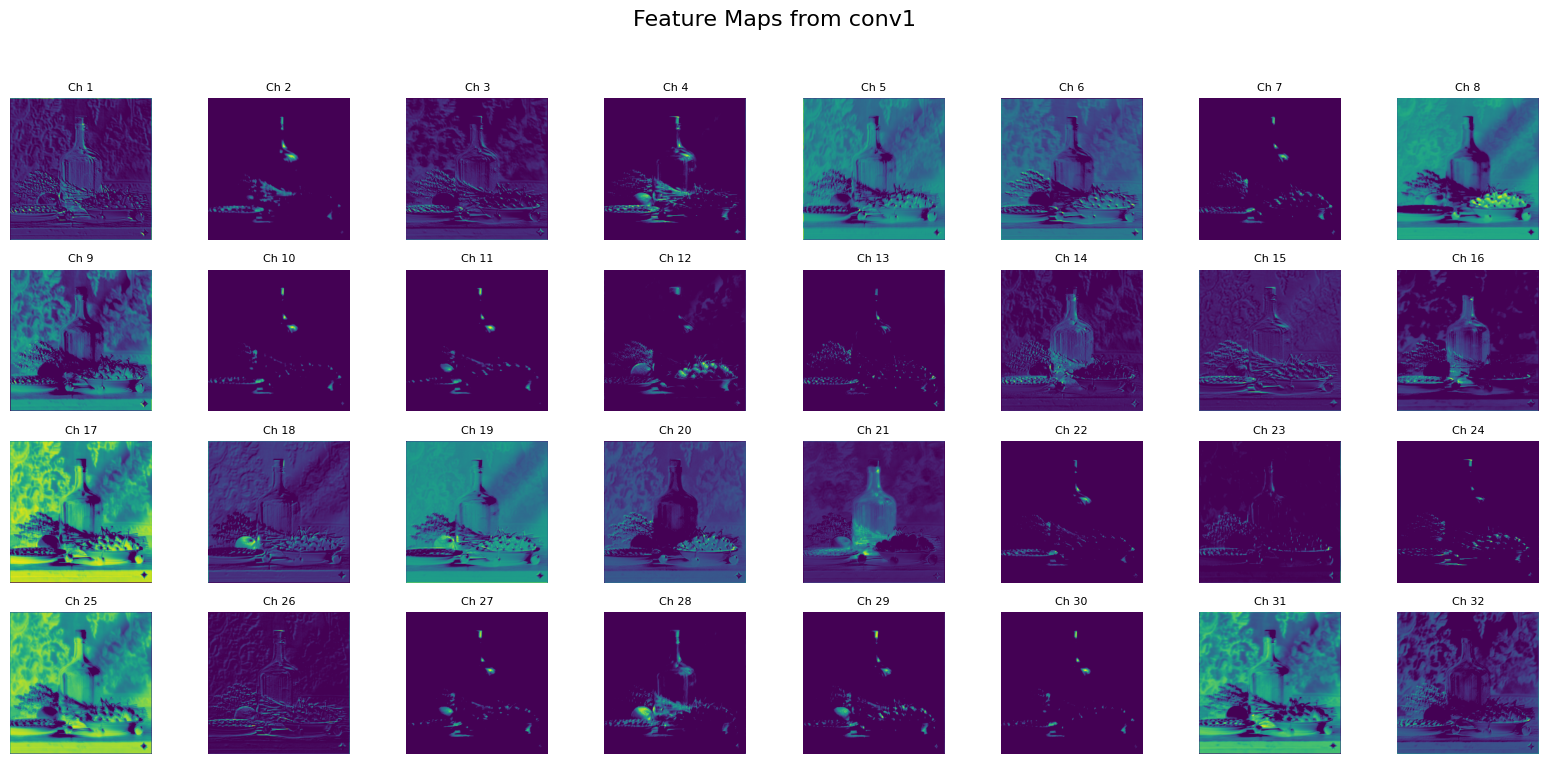


--- conv2 특징 맵 (32 채널) 시각화 ---


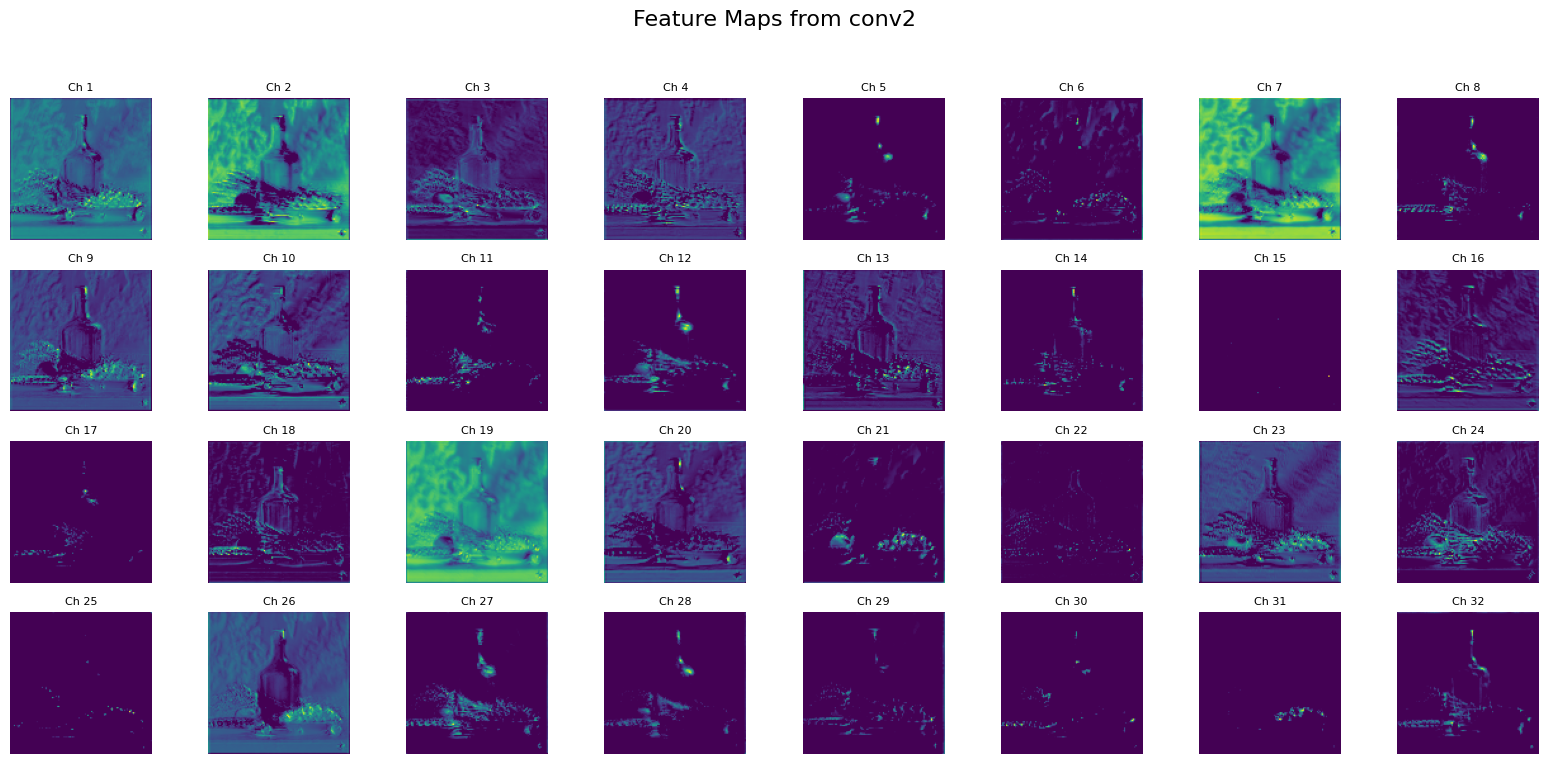


--- 시각화된 특징 맵이 화면에 표시됩니다. ---


In [51]:
# --- 메인 실행 ---
if __name__ == "__main__":
    image_path = 'img1.png' # 시각화할 이미지 파일 경로
    input_tensor = load_and_preprocess_image(image_path)

    if input_tensor is not None:
        model = SimpleCNN(num_classes=10)
        # 모델을 평가 모드로 설정 (드롭아웃, 배치 정규화 등에 영향)
        model.eval()

        with torch.no_grad(): # 역전파 계산 비활성화 (메모리 절약)
            _ = model(input_tensor) # forward를 실행하여 feature_maps에 특징 맵 저장

        visualize_feature_maps(model.feature_maps)

        print("\n--- 시각화된 특징 맵이 화면에 표시됩니다. ---")

### . Batch_Normalization(배치 정규화)
- 검색하여정리: Batch_Normalization와 bias의 관계
- 배치 정규화(Batch Normalization, BN)는 딥러닝 모델의 학습 속도를 개선하고 성능을 안정화시키기 위해 2015년에 소개된 기술입니다. 이는 신경망의 각 계층에 들어가는 입력의 분포를 정규화하여 학습을 돕는 방법입니다.

💡 작동 원리
배치 정규화는 훈련하는 동안 미니 배치(mini-batch) 단위로 작동하며, 각 특징(feature, 즉 뉴런의 출력)의 분포를 평균이 0이고 분산이 1인 정규분포에 가깝게 조정합니다.


In [42]:
class SimpleCNN_BatchNormalization(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN_BatchNormalization, self).__init__()

        # 첫 번째 Conv Block
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 두 번째 Conv Block
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # 전결합층
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, num_classes)

        # 특징맵 저장용
        self.feature_maps = {}

    def forward(self, x):
        # Conv1 → BN → ReLU → Pool
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        self.feature_maps['conv1_bn'] = x.clone().detach()
        x = self.pool(x)

        # Conv2 → BN → ReLU → Pool
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        self.feature_maps['conv2_bn'] = x.clone().detach()
        x = self.pool(x)

        # Flatten + Fully Connected
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


이미지 'img1.png' 로드 및 전처리 완료. 텐서 크기: torch.Size([1, 3, 224, 224])

--- conv1_bn 특징 맵 (16 채널) 시각화 ---


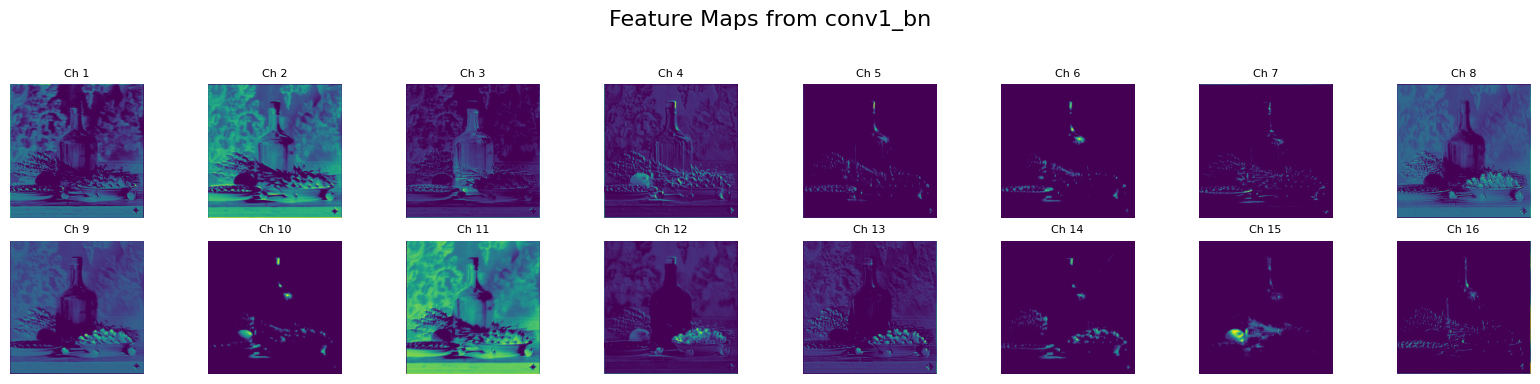


--- conv2_bn 특징 맵 (32 채널) 시각화 ---


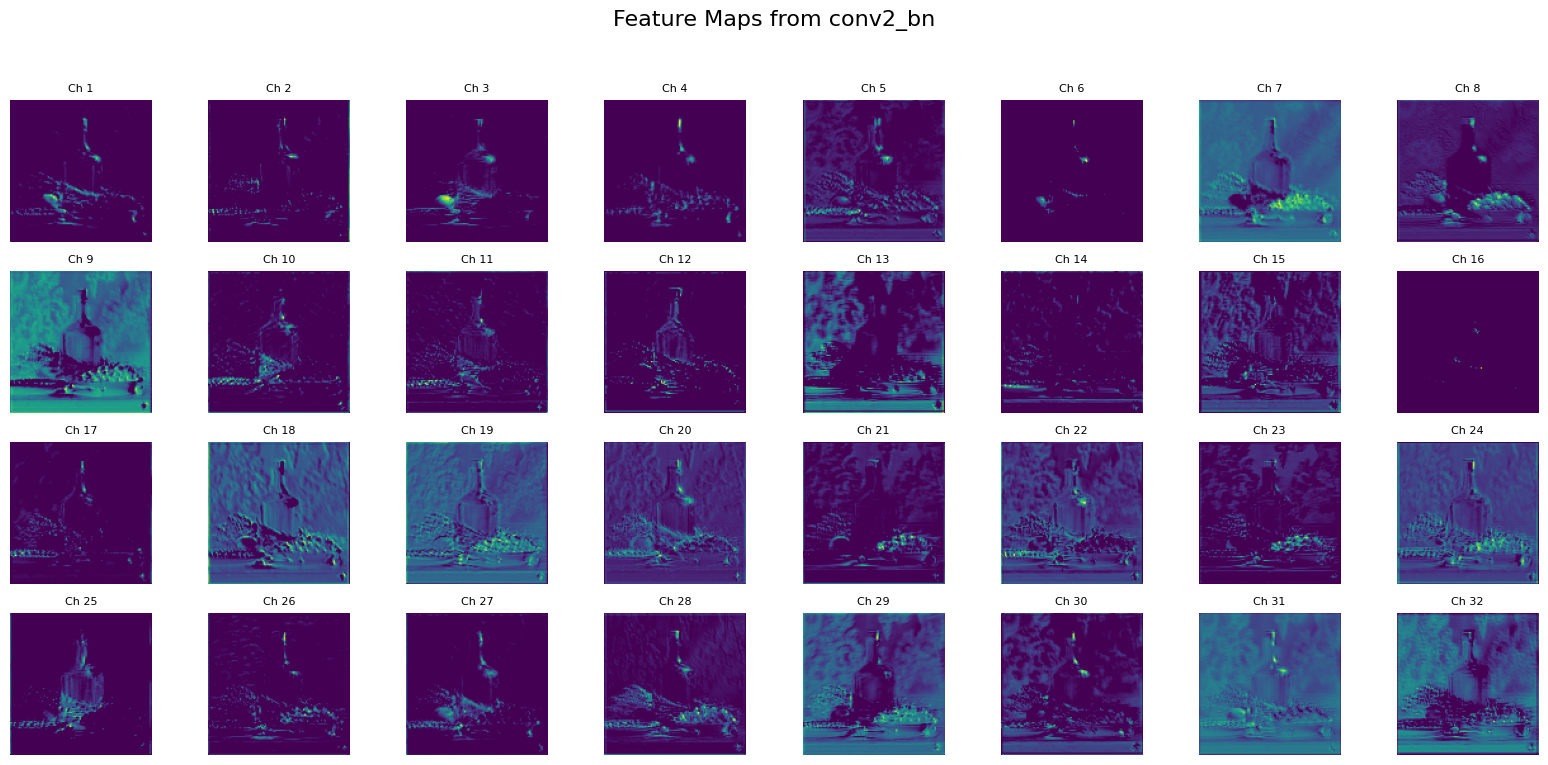


--- 시각화된 특징 맵이 화면에 표시됩니다. ---


In [43]:
# --- 메인 실행 ---
if __name__ == "__main__":
    image_path = 'img1.png' # 시각화할 이미지 파일 경로
    input_tensor = load_and_preprocess_image(image_path)

    if input_tensor is not None:
        model = SimpleCNN_BatchNormalization(num_classes=10)
        # 모델을 평가 모드로 설정 (드롭아웃, 배치 정규화 등에 영향)
        model.eval()

        with torch.no_grad(): # 역전파 계산 비활성화 (메모리 절약)
            _ = model(input_tensor) # forward를 실행하여 feature_maps에 특징 맵 저장

        visualize_feature_maps(model.feature_maps)

        print("\n--- 시각화된 특징 맵이 화면에 표시됩니다. ---")

### .Adaptive Pool (사전학습에 사용됨)
- 검색하여정리: 어댑티브 풀링을 사용하는 이유 (필요성)
- 어댑티브 풀링(Adaptive Pooling)은 주로 합성곱 신경망(CNN)에서 사용되는 풀링 계층의 한 종류로, 입력 텐서의 크기에 관계없이 출력 텐서의 크기를 항상 고정시키는 기술로서 Fully Connected Layer (FC Layer, 전결합 계층)에 연결하기 직전에 사용됩니다.

- 작동 원리 및 목적일반적인 풀링(MaxPool2d, AvgPool2d)은 kernel_size와 stride를 고정하여 입력 크기에 따라 출력 크기가 달라집니다.
-  반면, 어댑티브 풀링은 정반대로 작동합니다.
  - 1. 고정된 출력 크기 보장어댑티브 풀링 계층을 정의할 때, 개발자는 원하는 **최종 출력 크기 (H x W)**만 지정합니다.
    - 예를 들어, torch.nn.AdaptiveAvgPool2d((1, 1))은 입력 이미지가 224*224이든 552*552이든 1*1 크기의 출력 특징 맵을 생성합니다.


          - AdaptiveAvgPool2d: 각 출력 위치의 값을 계산하기 위해 입력 영역의 평균값을 사용합니다. (가장 흔하게 사용됨)
          - AdaptiveMaxPool2d: 각 출력 위치의 값을 계산하기 위해 입력 영역의 최댓값을 사용합니다

In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# 활성화 분포:  활성화가 매우 강한 채널이 있는 반면, 거의 활성화되지 않은 (어두운) 채널도 많이 보입니다.
# 정보의 활용: 일부 채널은 매우 강한 특징을 포착하지만, 다른 채널은 상대적으로 정보가 부족해 보입니다.
# 명확성 및 선명도: 일부 특징 맵은 노이즈처럼 보이거나 전반적으로 어둡고 활성화가 덜 명확합니다.
#---------------------------------------------------------------------

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=6, stride=2, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=6, stride=2, padding=1)

        # Adaptive Average Pool로 크기 자동 맞춤
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        # 출력 채널(32)만 입력으로 받는 FC
        self.fc1 = nn.Linear(32, 128)
        self.fc2 = nn.Linear(128, num_classes)

        # 특징맵 저장용
        self.feature_maps = {}

    def forward(self, x):
        # Conv1
        x = F.relu(self.conv1(x))
        self.feature_maps['conv1'] = x.clone().detach()
        x = self.pool(x)

        # Conv2
        x = F.relu(self.conv2(x))
        self.feature_maps['conv2'] = x.clone().detach()
        x = self.pool(x)

        # Adaptive Pool → Flatten → FC
        x = self.adaptive_pool(x)  # (batch, 32, 1, 1)
        x = torch.flatten(x, 1)    # (batch, 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


# --------------------------------------------------------------
# 예시 실행 코드
# --------------------------------------------------------------
if __name__ == "__main__":
    model = SimpleCNN()
    img_tensor = torch.randn(1, 3, 128, 128)  # 어떤 크기든 OK (64,128,224,512...)
    out = model(img_tensor)
    print("출력 크기:", out.shape)  # torch.Size([1, 10])


출력 크기: torch.Size([1, 10])


이미지 'img1.png' 로드 및 전처리 완료. 텐서 크기: torch.Size([1, 3, 224, 224])

--- conv1 특징 맵 (32 채널) 시각화 ---


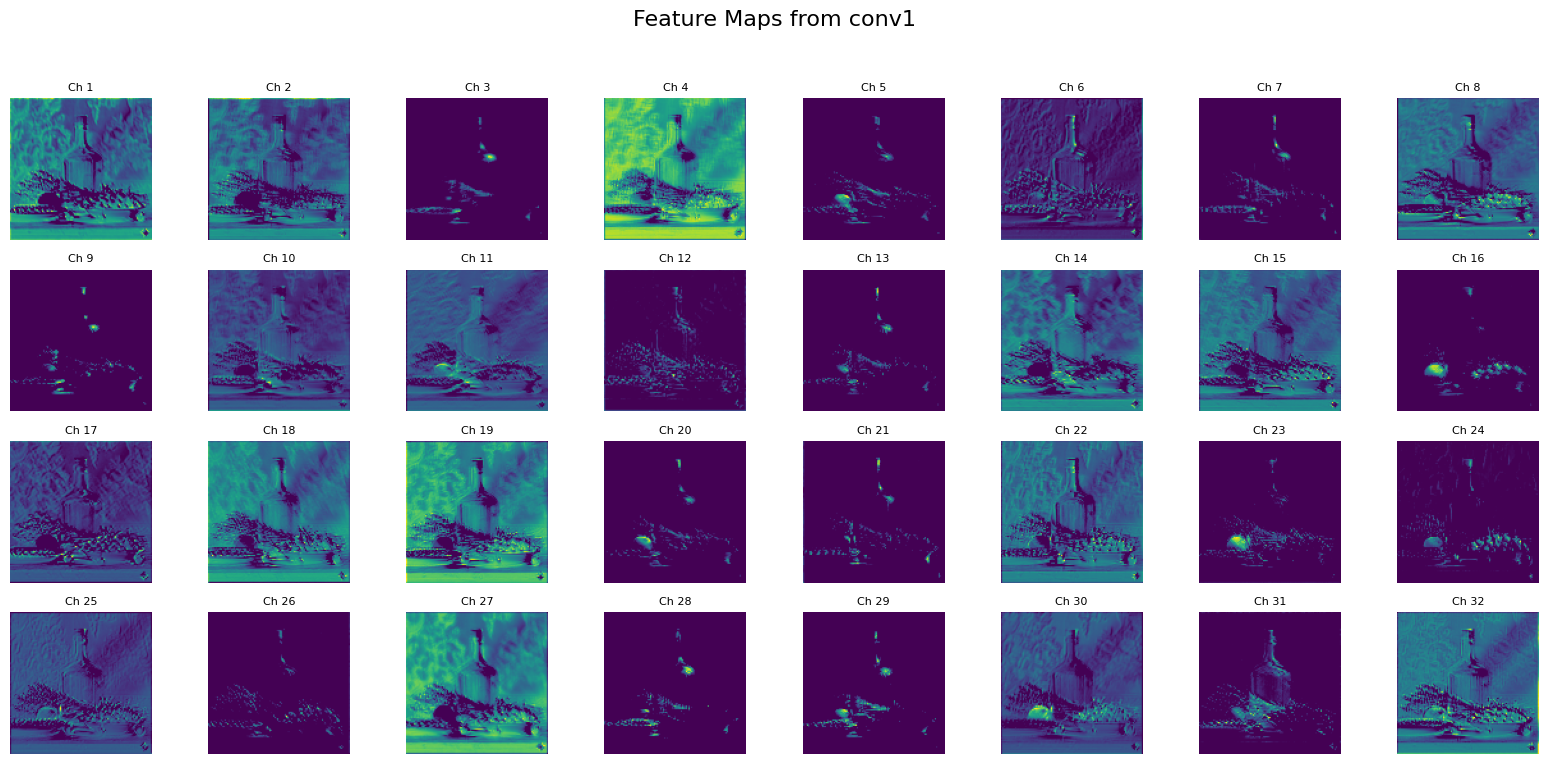


--- conv2 특징 맵 (32 채널) 시각화 ---


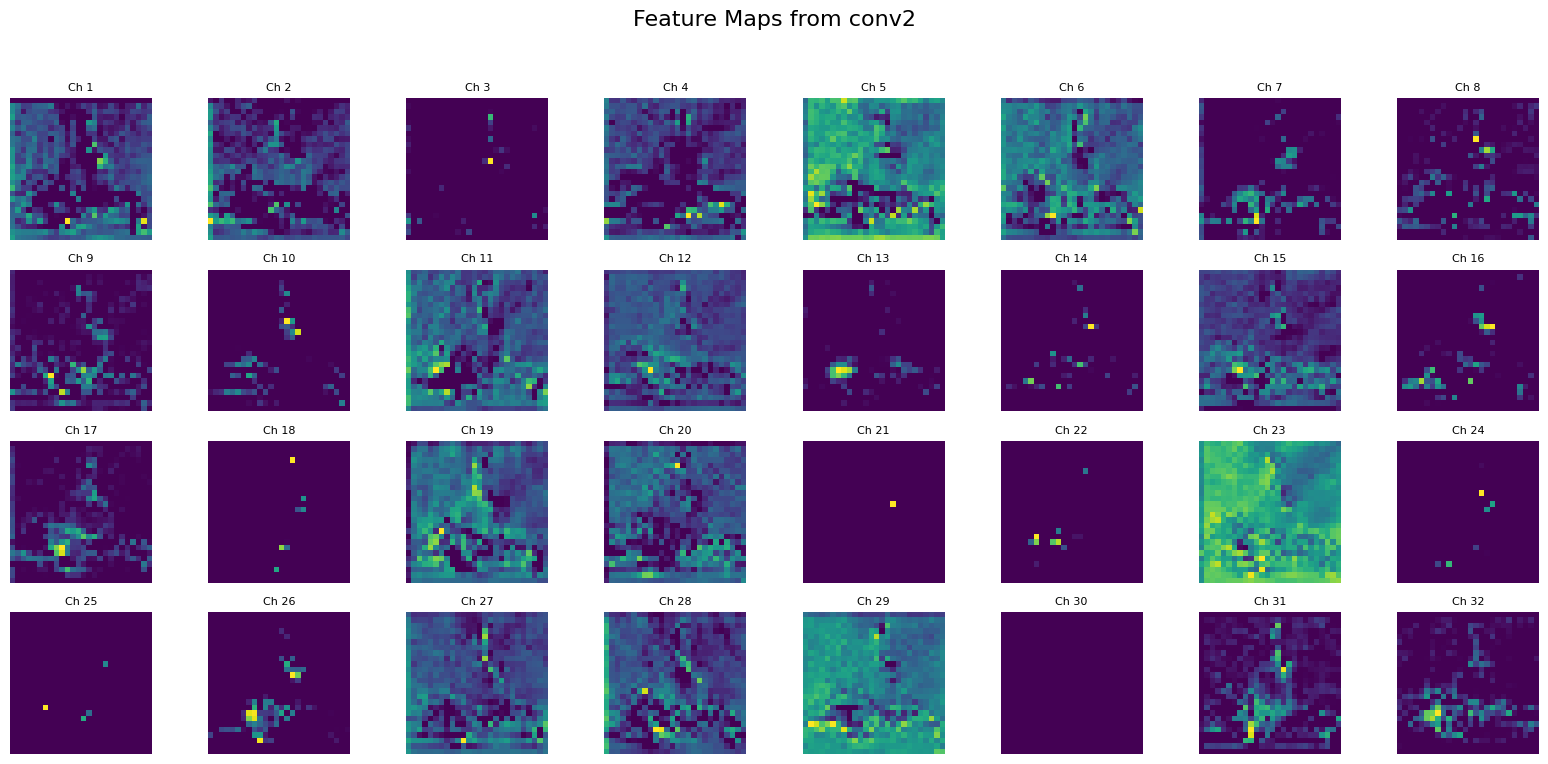


--- 시각화된 특징 맵이 화면에 표시됩니다. ---


In [58]:
# --- 메인 실행 ---
if __name__ == "__main__":
    image_path = 'img1.png' # 시각화할 이미지 파일 경로
    input_tensor = load_and_preprocess_image(image_path)

    if input_tensor is not None:
        model = SimpleCNN(num_classes=10)
        # 모델을 평가 모드로 설정 (드롭아웃, 배치 정규화 등에 영향)
        model.eval()

        with torch.no_grad(): # 역전파 계산 비활성화 (메모리 절약)
            _ = model(input_tensor) # forward를 실행하여 feature_maps에 특징 맵 저장

        visualize_feature_maps(model.feature_maps)

        print("\n--- 시각화된 특징 맵이 화면에 표시됩니다. ---")

## [3] VGG모델에 넣어서

Layer 1: shape=torch.Size([64, 32, 32])


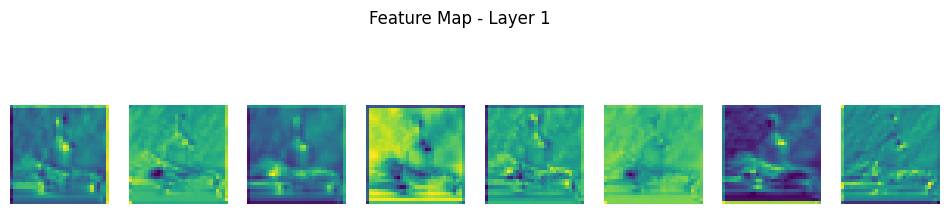

Layer 2: shape=torch.Size([64, 32, 32])


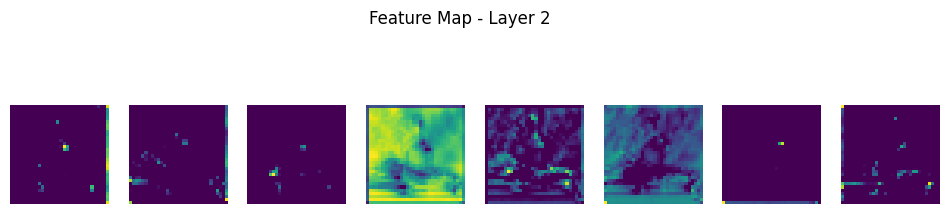

Layer 3: shape=torch.Size([64, 32, 32])


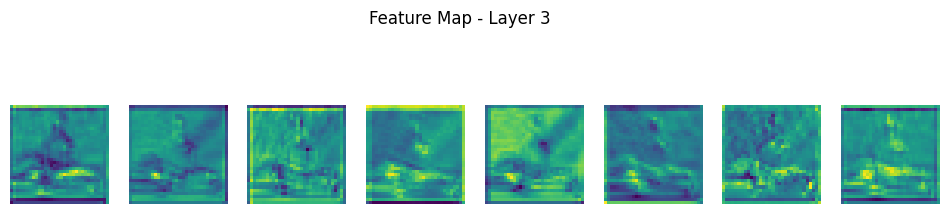


--- 시각화 완료 ---


In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------------
#  VGG 구성
# -----------------------------------
cfg_vgg16 = [64, 64, 'M', 128, 128, 'M',
              256, 256, 256, 'M',
              512, 512, 512, 'M',
              512, 512, 512, 'M']

class VGG(nn.Module):
    def __init__(self, cfg, batch_norm=False, num_classes=10, init_weights=True):
        super(VGG, self).__init__()
        self.features = self.make_layers(cfg, batch_norm)
        # CIFAR10 입력(32×32)이므로 7x7이 아니라 1x1로 맞춤
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )
        if init_weights:
            self._initialize_weights()
        self.feature_maps = []  # 특징맵 저장용

    def forward(self, x):
        self.feature_maps = []
        for layer in self.features:
            x = layer(x)
            # Conv2d나 ReLU만 저장 (시각화용)
            if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.ReLU):
                self.feature_maps.append(x.detach().cpu())
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def make_layers(self, cfg, batch_norm=False):
        layers = []
        in_channels = 3
        for v in cfg:
            if v == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
                if batch_norm:
                    layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
                else:
                    layers += [conv2d, nn.ReLU(inplace=True)]
                in_channels = v
        return nn.Sequential(*layers)

# -----------------------------------
#  이미지 로드 + 전처리
# -----------------------------------
def load_and_preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((32, 32)),  # CIFAR10 크기
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])
    try:
        img = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"❌ 이미지 '{image_path}'을 찾을 수 없습니다.")
        return None
    return transform(img).unsqueeze(0)

# -----------------------------------
#  특징맵 시각화 함수
# -----------------------------------
def visualize_feature_maps(feature_maps, num_layers=3):
    for idx, fmap in enumerate(feature_maps[:num_layers]):
        fmap = fmap.squeeze(0)
        n_channels = fmap.shape[0]
        print(f"Layer {idx+1}: shape={fmap.shape}")
        plt.figure(figsize=(12, 3))
        for i in range(min(8, n_channels)):
            plt.subplot(1, 8, i+1)
            plt.imshow(fmap[i].numpy(), cmap='viridis')
            plt.axis('off')
        plt.suptitle(f'Feature Map - Layer {idx+1}')
        plt.show()

# -----------------------------------
#  메인 실행
# -----------------------------------
if __name__ == "__main__":
    image_path = 'img1.png'
    input_tensor = load_and_preprocess_image(image_path)

    if input_tensor is not None:
        model = VGG(cfg_vgg16, batch_norm=True, num_classes=10)
        model.eval()
        with torch.no_grad():
            _ = model(input_tensor)
        visualize_feature_maps(model.feature_maps)
        print("\n--- 시각화 완료 ---")


## [4] ResNet구조로
- VGG는 단순한 conv 쌓기 구조지만, ResNet은 Residual Block(잔차 연결) 이 포함된 현대적 구조임

Layer 1: shape=torch.Size([64, 32, 32])


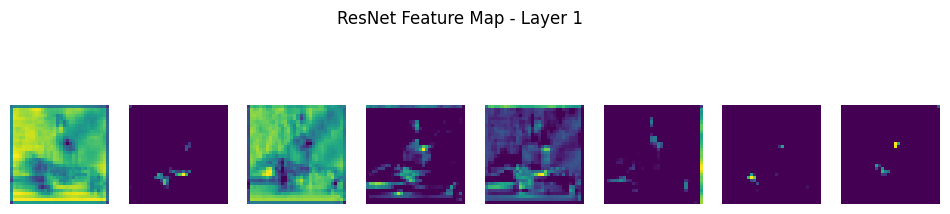

Layer 2: shape=torch.Size([64, 32, 32])


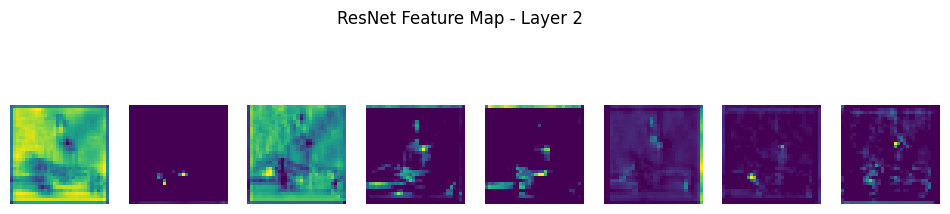

Layer 3: shape=torch.Size([128, 16, 16])


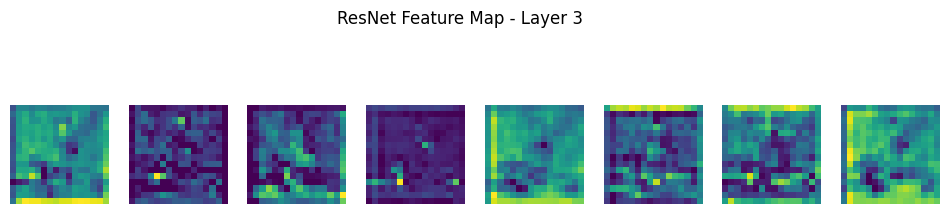

Layer 4: shape=torch.Size([256, 8, 8])


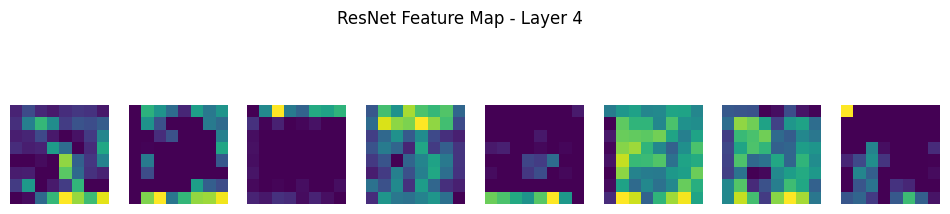

Layer 5: shape=torch.Size([512, 4, 4])


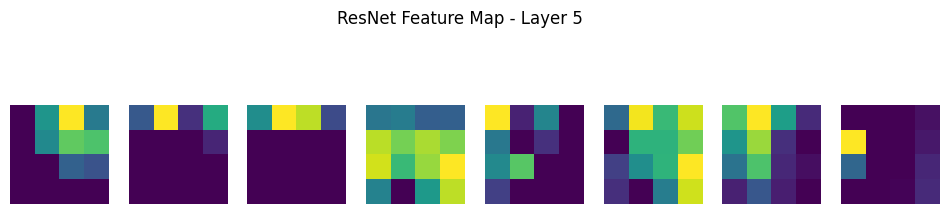


--- ResNet Feature Map 시각화 완료 ---


In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ------------------------------------------------
# Basic Residual Block
# ------------------------------------------------
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


# ------------------------------------------------
#  ResNet (CIFAR-10용)
# ------------------------------------------------
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.feature_maps = []  # 🔹 VGG처럼 feature map 저장용

        # conv1 (32x32 유지)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=False)

        # residual layers
        self.layer1 = self._make_layer(block, 64,  layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        self.feature_maps = []  # reset

        # 입력 conv
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        self.feature_maps.append(x.detach().cpu())

        # residual stages
        x = self.layer1(x); self.feature_maps.append(x.detach().cpu())
        x = self.layer2(x); self.feature_maps.append(x.detach().cpu())
        x = self.layer3(x); self.feature_maps.append(x.detach().cpu())
        x = self.layer4(x); self.feature_maps.append(x.detach().cpu())

        # classifier
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# ------------------------------------------------
#  CIFAR10용 ResNet18 생성
# ------------------------------------------------
def ResNet18_CIFAR10():
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)


# ------------------------------------------------
#  이미지 전처리
# ------------------------------------------------
def load_and_preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),
                             (0.5, 0.5, 0.5))
    ])
    img = Image.open(image_path).convert("RGB")
    return transform(img).unsqueeze(0)


# ------------------------------------------------
#  feature map 시각화 (VGG 스타일)
# ------------------------------------------------
def visualize_feature_maps(feature_maps, num_layers=5):
    for idx, fmap in enumerate(feature_maps[:num_layers]):
        fmap = fmap.squeeze(0)  # (C,H,W)
        n_channels = fmap.shape[0]
        print(f"Layer {idx+1}: shape={fmap.shape}")

        plt.figure(figsize=(12, 3))
        for i in range(min(8, n_channels)):  # 처음 8개만 출력
            plt.subplot(1, 8, i+1)
            plt.imshow(fmap[i].numpy(), cmap='viridis')
            plt.axis('off')
        plt.suptitle(f'ResNet Feature Map - Layer {idx+1}')
        plt.show()


# ------------------------------------------------
#  메인 실행
# ------------------------------------------------
if __name__ == "__main__":
    image_path = 'img1.png'
    input_tensor = load_and_preprocess_image(image_path)

    model = ResNet18_CIFAR10()
    model.eval()
    with torch.no_grad():
        _ = model(input_tensor)

    visualize_feature_maps(model.feature_maps)
    print("\n--- ResNet Feature Map 시각화 완료 ---")
